# DI725 Assignment 3 — QLoRA Fine-Tuning of PaliGemma on RISC

Fine-tunes **PaliGemma-3B** with **QLoRA** on the full RISC remote-sensing image captioning dataset (`caglarmert/full_riscm`), following the Lab-5 approach.

| Step | Description |
|---|---|
| 1 | Install & import |
| 2 | Load RISC dataset |
| 3 | Baseline evaluation (pre-trained, no LoRA) |
| 4 | QLoRA fine-tuning |
| 5 | Results visualisation (≥5 images) |
| 6 | Performance metrics (BLEU-4, METEOR, ROUGE-L) |

## 1. Install dependencies

In [4]:
%%capture
!pip install -q -U bitsandbytes
!pip install -q transformers datasets peft accelerate
!pip install -q nltk rouge-score pillow tqdm

In [5]:
import os, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from datasets import load_dataset
from transformers import (
    AutoProcessor,
    PaliGemmaForConditionalGeneration,
    PaliGemmaProcessor,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
)
from peft import get_peft_model, LoraConfig

import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer as rouge_lib

nltk.download('wordnet',  quiet=True)
nltk.download('punkt',    quiet=True)
nltk.download('omw-1.4',  quiet=True)
nltk.download('punkt_tab',quiet=True)

print('Imports OK')
print('CUDA:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU :', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory/1024**3, 1), 'GB')

Imports OK
CUDA: True
GPU : NVIDIA A100-SXM4-40GB
VRAM: 39.5 GB


In [6]:
from huggingface_hub import login

HF_TOKEN = 'hf_YOUR_TOKEN_HERE'
login(token=HF_TOKEN)
print('Logged in to HuggingFace.')

Logged in to HuggingFace.


In [7]:
# ── GLOBAL CONFIG ──────────────────────────────────────────────
MODEL_ID    = 'google/paligemma-3b-pt-224'
DATASET_ID  = 'caglarmert/full_riscm'
OUTPUT_DIR  = 'finetuned_paligemma_riscm_full'
device      = 'cuda'

# LoRA
LORA_R      = 8

TRAIN_BATCH = 4
GRAD_ACCUM  = 4
LR          = 2e-5
EPOCHS      = 1

# Evaluation
NUM_TEST_METRIC  = 200   # test samples used for metric computation
NUM_DISPLAY      = 5     # images shown in visualisation

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print('Config ready.')
print(f'  Effective batch size: {TRAIN_BATCH * GRAD_ACCUM}')

Config ready.
  Effective batch size: 16


## 2. Load RISC Dataset

In [8]:
print('Loading full RISC dataset…')
ds = load_dataset(DATASET_ID)
print(ds)
print('Features:', ds['train'].features)

Loading full RISC dataset…


README.md:   0%|          | 0.00/482 [00:00<?, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/384M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/358M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/375M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/44521 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'caption_1', 'caption_2', 'caption_3', 'caption_4', 'caption_5'],
        num_rows: 44521
    })
})
Features: {'image': Image(mode=None, decode=True), 'caption_1': Value('string'), 'caption_2': Value('string'), 'caption_3': Value('string'), 'caption_4': Value('string'), 'caption_5': Value('string')}


In [9]:
# Inspect one example
ex = ds['train'][0]
print('All keys:', list(ex.keys()))
for k, v in ex.items():
    if k == 'image':
        print(f'  {k}: {type(v).__name__}, size={getattr(v, "size", "?")}')
    else:
        print(f'  {k}: {str(v)[:120]}')

All keys: ['image', 'caption_1', 'caption_2', 'caption_3', 'caption_4', 'caption_5']
  image: JpegImageFile, size=(224, 224)
  caption_1: A gray plane on the runway and the lawn beside .
  caption_2: A grey plane is on the runway by the lawn .
  caption_3: There is an airplane on the runway with a large lawn by the runway .
  caption_4: A plane is parked on the runway next to the grass .
  caption_5: There is a plane on the runway beside the grass .


In [10]:
# Train / test split
split_ds = ds['train'].train_test_split(test_size=0.05, seed=SEED)
train_ds = split_ds['train']
test_ds  = split_ds['test']
print(f'Train: {len(train_ds):,}  |  Test: {len(test_ds):,}')

Train: 42,294  |  Test: 2,227


In [11]:
def find_caption_col(features):
    # Exact matches first
    for name in ['caption', 'captions', 'text', 'description',
                  'caption_1', 'caption1', 'cap1', 'sentence', 'sent1']:
        if name in features:
            return name
    # Fuzzy: any column whose name contains a hint
    for k in features:
        if any(x in k.lower() for x in ['cap', 'sent', 'desc', 'text']):
            return k
    raise ValueError(f'Cannot find a caption column. Available: {list(features.keys())}')

CAPTION_COL = find_caption_col(train_ds.features)
print(f'Caption column : {CAPTION_COL!r}')

# Check whether the value is a list (multiple captions) or a string (single)
_sample_val = train_ds[0][CAPTION_COL]
CAPTION_IS_LIST = isinstance(_sample_val, list)
print(f'Value type     : {"list of " + str(len(_sample_val)) + " strings" if CAPTION_IS_LIST else "string"}')
print(f'Example        : {str(_sample_val[0] if CAPTION_IS_LIST else _sample_val)[:120]}')

def get_caption(row, idx=0):
    """Return one caption string from a dataset row, regardless of storage format."""
    val = row[CAPTION_COL]
    if isinstance(val, list):
        return val[idx]
    return str(val)

Caption column : 'caption_1'
Value type     : string
Example        : The deep blue river has a white floodplain and a residential area is next to the river .


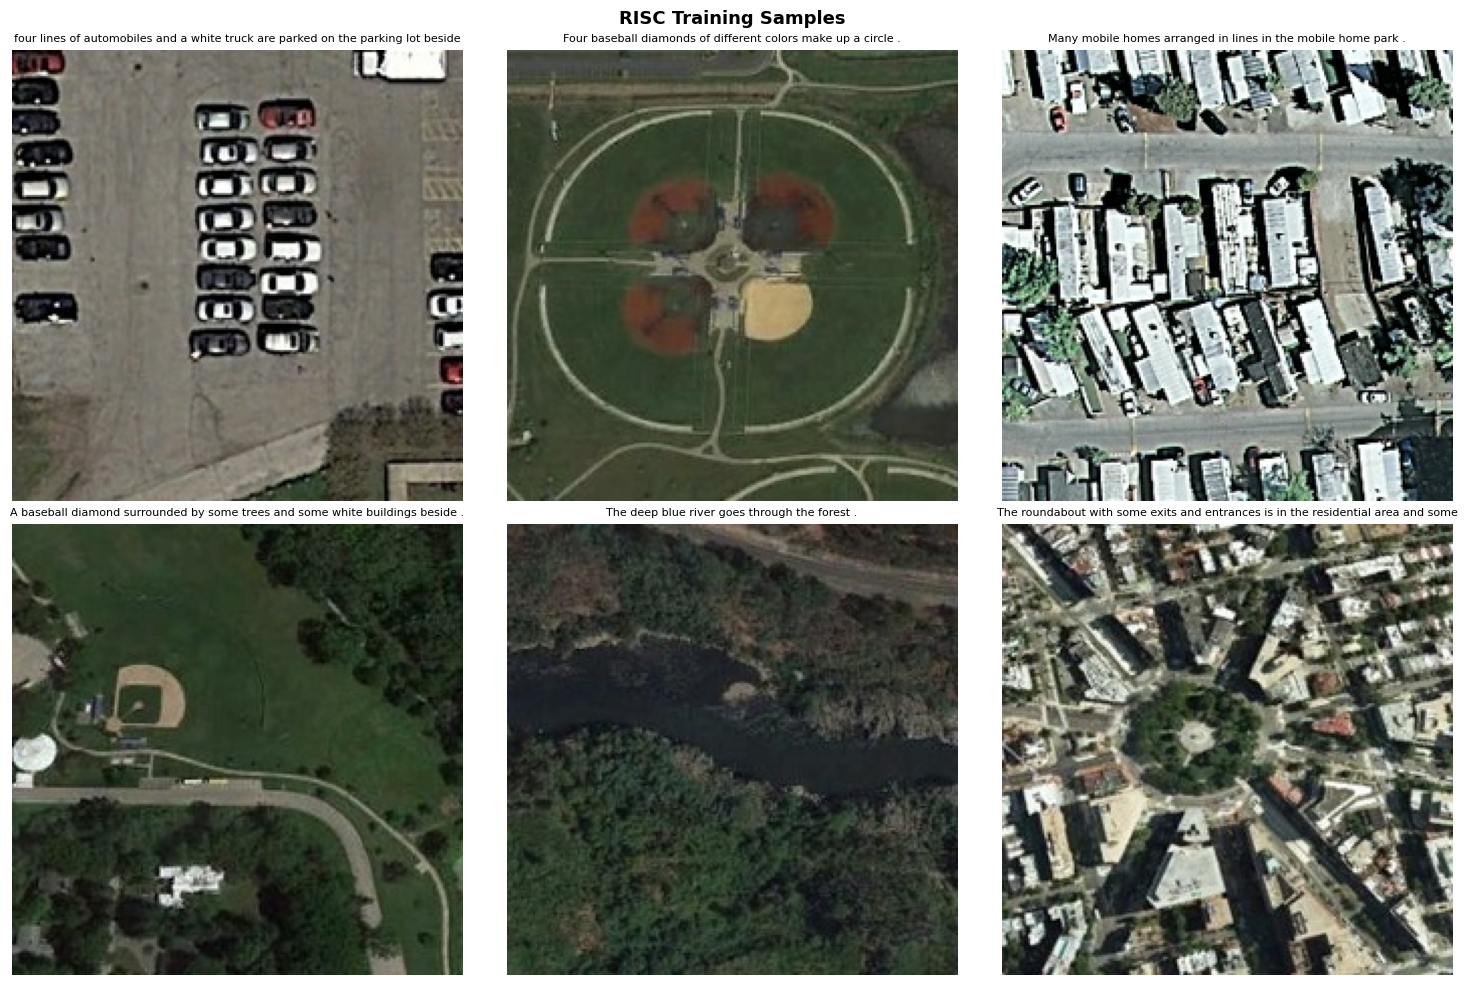

In [12]:
#Visualization of some training images
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, idx in zip(axes.flatten(), random.sample(range(len(train_ds)), 6)):
    ex = train_ds[idx]
    ax.imshow(ex['image'])
    ax.set_title(get_caption(ex)[:80], fontsize=8, wrap=True)
    ax.axis('off')
plt.suptitle('RISC Training Samples', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('risc_samples.png', dpi=100, bbox_inches='tight')
plt.show()

## 3. Load Processor & Baseline Model

I run inference with the **unmodified** pre-trained model first, to record baseline captions. The same 4-bit quantised model then gets LoRA adapters for fine-tuning.

In [13]:
processor = PaliGemmaProcessor.from_pretrained(MODEL_ID, token=HF_TOKEN)
print('Processor loaded.')

preprocessor_config.json:   0%|          | 0.00/699 [00:00<?, ?B/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.26M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/607 [00:00<?, ?B/s]

Processor loaded.


In [14]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16,
)

print('Loading PaliGemma-3B with 4-bit quantisation…')
model = PaliGemmaForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map={'': 0},
    token=HF_TOKEN,
)
print('Model loaded.')
total = sum(p.numel() for p in model.parameters())
print(f'  Total parameters: {total:,}')

Loading PaliGemma-3B with 4-bit quantisation…


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/603 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

Model loaded.
  Total parameters: 1,725,847,280


In [15]:
# Baseline inference helper
PROMPT = 'describe this image.'

@torch.no_grad()
def generate_caption(mdl, proc, image, max_new_tokens=80):
    """Generate one caption for a PIL image."""
    if not isinstance(image, Image.Image):
        image = image['image']          # accept dataset row dict too
    inputs = proc(image.convert('RGB'), PROMPT, return_tensors='pt').to(device)
    out = mdl.generate(**inputs, max_new_tokens=max_new_tokens)
    decoded = proc.decode(out[0], skip_special_tokens=True)
    return decoded[len(PROMPT):].strip()

# Sanity check
model.eval()
print('Baseline test caption:')
print(generate_caption(model, processor, test_ds[0]['image']))

You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.


Baseline test caption:
The airport in 2006


In [16]:
# Collect baseline captions and ground-truth for the fixed test subset
n_metric = min(NUM_TEST_METRIC, len(test_ds))
test_indices = list(range(n_metric))

print(f'Generating baseline captions for {n_metric} test samples…')
baseline_caps = []
gt_caps       = []

for i in tqdm(test_indices):
    row = test_ds[i]
    gt_caps.append(get_caption(row))                              # ← uses detected column
    baseline_caps.append(generate_caption(model, processor, row['image']))

print('Done. Sample results:')
for i in range(3):
    print(f'  GT       : {gt_caps[i]}')
    print(f'  Baseline : {baseline_caps[i]}')
    print()

Generating baseline captions for 200 test samples…


  0%|          | 0/200 [00:00<?, ?it/s]

You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
Y

Done. Sample results:
  GT       : some planes are near several buildings in an airport .
  Baseline : The airport in 2006

  GT       : A straight freeway goes through the lawn and some cars are driving on the freeway .
  Baseline : The accident occurred on the northbound lanes of I-35.

  GT       : The roundabout with some exits and entrances is in the commercial area and a lawn is in the middle of the roundabout .
  Baseline : Plaza de la República



## 4. QLoRA Fine-Tuning

Follows the Lab-5 QLoRA setup exactly, scaled to the full RISC dataset.

In [17]:
# LoRA config — matches Lab 5
lora_config = LoraConfig(
    r=LORA_R,
    target_modules=['q_proj', 'o_proj', 'k_proj', 'v_proj',
                    'gate_proj', 'up_proj', 'down_proj'],
    task_type='CAUSAL_LM',
)

model.train()
model.config.use_cache = False
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 11,298,816 || all params: 2,934,765,296 || trainable%: 0.3850


In [18]:
# Collate function
def collate_fn(examples):
    texts  = ['<image> describe this image.' for _ in examples]
    labels = [get_caption(ex) for ex in examples]                # ← uses detected column
    images = [ex['image'].convert('RGB') for ex in examples]
    tokens = processor(
        text=texts, images=images, suffix=labels,
        return_tensors='pt', padding='longest',
    )
    tokens = tokens.to(torch.bfloat16).to(device)
    return tokens

# Quick check
sample = collate_fn([train_ds[0], train_ds[1]])
print('Collator output keys:', list(sample.keys()))
for k, v in sample.items():
    if hasattr(v, 'shape'):
        print(f'  {k}: {v.shape}')

Collator output keys: ['input_ids', 'token_type_ids', 'attention_mask', 'pixel_values', 'labels']
  input_ids: torch.Size([2, 281])
  token_type_ids: torch.Size([2, 281])
  attention_mask: torch.Size([2, 281])
  pixel_values: torch.Size([2, 3, 224, 224])
  labels: torch.Size([2, 281])


In [19]:
steps_per_epoch = len(train_ds) // (TRAIN_BATCH * GRAD_ACCUM)
print(f'Steps per epoch: ~{steps_per_epoch:,}')
print('Expected training time on A100: ~1–4 h for 1 epoch')

args = TrainingArguments(
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=TRAIN_BATCH,
    gradient_accumulation_steps=GRAD_ACCUM,
    warmup_steps=100,
    learning_rate=LR,
    weight_decay=1e-6,
    adam_beta2=0.999,
    logging_steps=200,
    optim='adamw_8bit',
    save_strategy='epoch',
    save_total_limit=1,
    output_dir=OUTPUT_DIR,
    bf16=True,
    dataloader_pin_memory=False,
    remove_unused_columns=False,
    report_to='none',
)

Steps per epoch: ~2,643
Expected training time on A100: ~1–4 h for 1 epoch


In [20]:
trainer = Trainer(
    model=model,
    train_dataset=train_ds,
    data_collator=collate_fn,
    args=args,
)

print('Starting QLoRA fine-tuning…')
result = trainer.train()
print('Training complete!')
print(f'  Final loss : {result.training_loss:.4f}')
print(f'  Time       : {result.metrics["train_runtime"]/3600:.2f} h')

Starting QLoRA fine-tuning…


Step,Training Loss
200,2.907906
400,1.849641
600,1.494044
800,1.285788
1000,1.190220
1200,1.141320
1400,1.042057
1600,1.048246
1800,1.021879
2000,0.943535


Training complete!
  Final loss : 1.2847
  Time       : 1.39 h


In [21]:
# Save LoRA weights and processor
model.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print(f'Model saved to ./{OUTPUT_DIR}')

Model saved to ./finetuned_paligemma_riscm_full


## 5. Results Visualisation

For ≥5 test images: ground-truth caption, baseline PaliGemma output, QLoRA fine-tuned output.

In [22]:
# Generate fine-tuned captions for the same test subset
model.eval()
model.config.use_cache = True

print(f'Generating fine-tuned captions for {n_metric} test samples…')
ft_caps = []
for i in tqdm(test_indices):
    ft_caps.append(generate_caption(model, processor, test_ds[i]['image']))

print('Done. Sample comparison:')
for i in range(3):
    print(f'  GT         : {gt_caps[i]}')
    print(f'  Baseline   : {baseline_caps[i]}')
    print(f'  Fine-tuned : {ft_caps[i]}')
    print()

Generating fine-tuned captions for 200 test samples…


  0%|          | 0/200 [00:00<?, ?it/s]

You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
Y

Done. Sample comparison:
  GT         : some planes are near several buildings in an airport .
  Baseline   : The airport in 2006
  Fine-tuned : The airport has two runways, one of which is closed.

  GT         : A straight freeway goes through the lawn and some cars are driving on the freeway .
  Baseline   : The accident occurred on the northbound lanes of I-35.
  Fine-tuned : The freeway is a straight freeway with some cars on the road.

  GT         : The roundabout with some exits and entrances is in the commercial area and a lawn is in the middle of the roundabout .
  Baseline   : Plaza de la República
  Fine-tuned : The square is surrounded by some buildings.



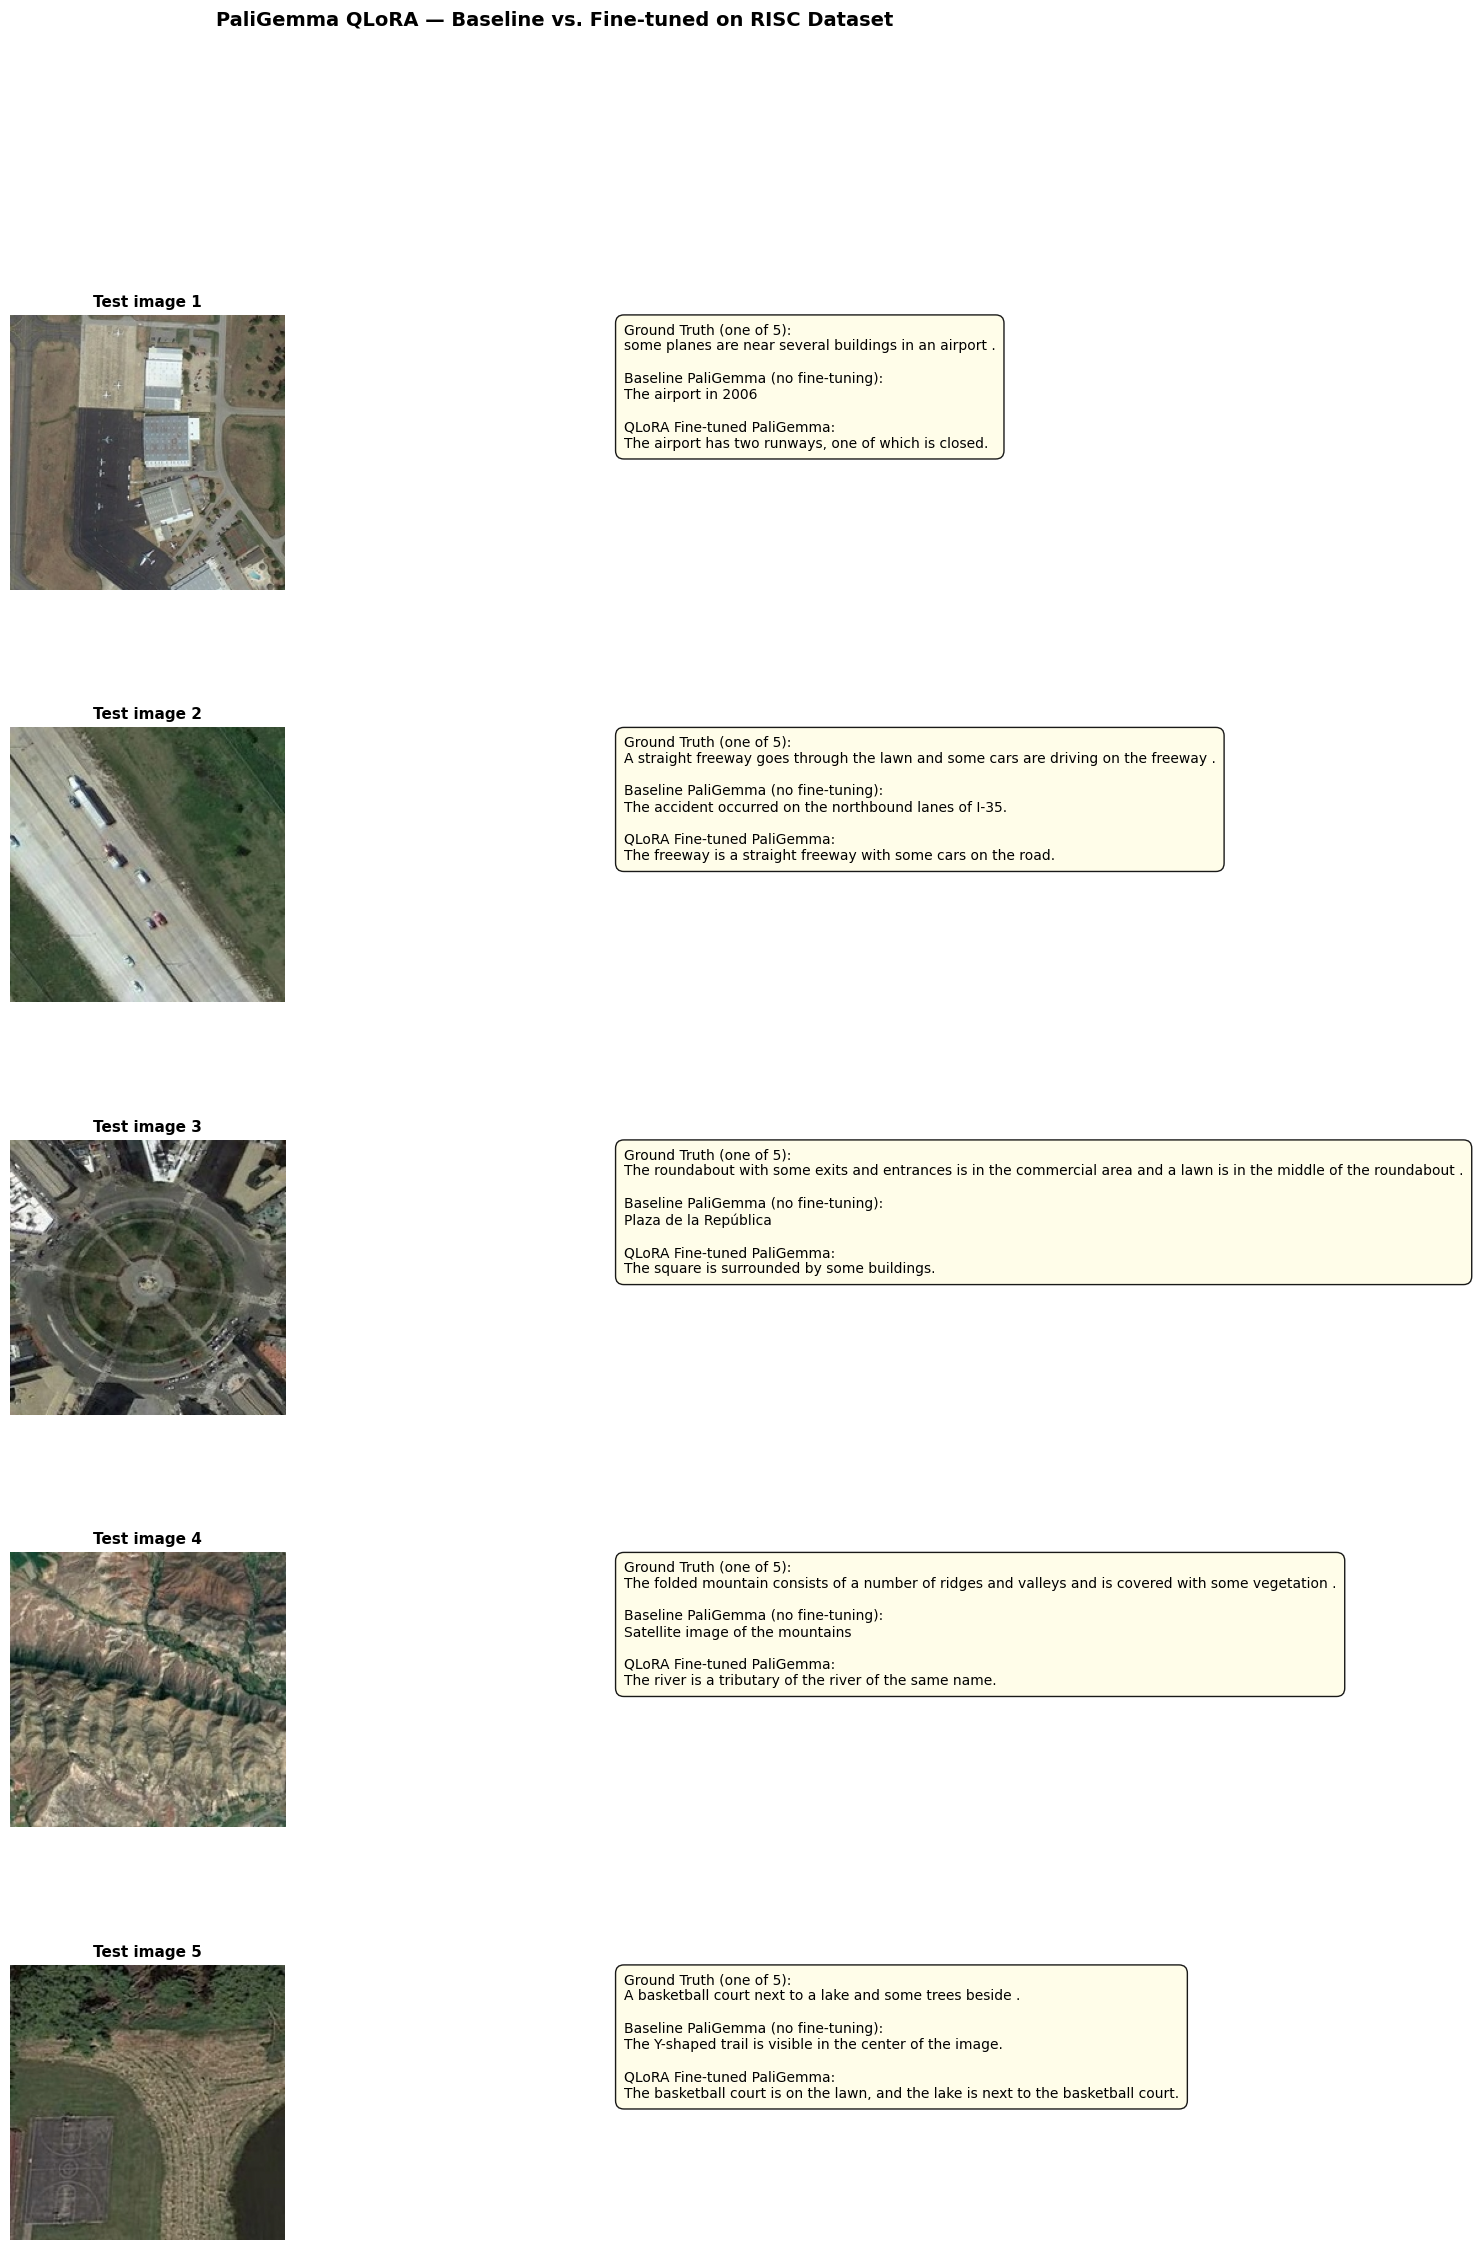

Saved results_visualization.png


In [23]:
n = NUM_DISPLAY
fig = plt.figure(figsize=(22, n * 5))
gs  = fig.add_gridspec(n, 2, hspace=0.5, wspace=0.04)

for i in range(n):
    row = test_ds[i]

    ax_img = fig.add_subplot(gs[i, 0])
    ax_img.imshow(row['image'])
    ax_img.set_title(f'Test image {i+1}', fontweight='bold', fontsize=11)
    ax_img.axis('off')

    ax_txt = fig.add_subplot(gs[i, 1])
    ax_txt.axis('off')
    content = (
        f'Ground Truth (one of 5):\n{gt_caps[i]}\n\n'
        f'Baseline PaliGemma (no fine-tuning):\n{baseline_caps[i]}\n\n'
        f'QLoRA Fine-tuned PaliGemma:\n{ft_caps[i]}'
    )
    ax_txt.text(
        0.03, 0.97, content,
        transform=ax_txt.transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.6', facecolor='#FFFDE7', alpha=0.9),
    )

fig.suptitle(
    'PaliGemma QLoRA — Baseline vs. Fine-tuned on RISC Dataset',
    fontsize=14, fontweight='bold', y=1.002,
)
plt.savefig('results_visualization.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved results_visualization.png')

## 6. Performance Metrics

We use **BLEU-4**, **METEOR**, and **ROUGE-L** to compare baseline vs. QLoRA fine-tuned PaliGemma. One ground-truth caption per test image is used as the reference (as required by the assignment).

In [24]:
def tok(text):
    return nltk.word_tokenize(text.lower())

def bleu4(refs, hyps):
    smooth = SmoothingFunction().method1
    return corpus_bleu(
        [[tok(r)] for r in refs], [tok(h) for h in hyps],
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smooth,
    )

def avg_meteor(refs, hyps):
    return float(np.mean([meteor_score([tok(r)], tok(h)) for r, h in zip(refs, hyps)]))

def avg_rouge_l(refs, hyps):
    scorer = rouge_lib.RougeScorer(['rougeL'], use_stemmer=True)
    return float(np.mean([scorer.score(r, h)['rougeL'].fmeasure for r, h in zip(refs, hyps)]))

print(f'Computing metrics on {n_metric} test samples…')

b_bleu   = bleu4(gt_caps, baseline_caps)
b_meteor = avg_meteor(gt_caps, baseline_caps)
b_rouge  = avg_rouge_l(gt_caps, baseline_caps)

f_bleu   = bleu4(gt_caps, ft_caps)
f_meteor = avg_meteor(gt_caps, ft_caps)
f_rouge  = avg_rouge_l(gt_caps, ft_caps)

print()
print(f'{"Metric":<12} {"Baseline":>12} {"QLoRA FT":>12} {"Δ":>10}')
print('─' * 50)
print(f'{"BLEU-4":<12} {b_bleu:>12.4f} {f_bleu:>12.4f} {f_bleu-b_bleu:>+10.4f}')
print(f'{"METEOR":<12} {b_meteor:>12.4f} {f_meteor:>12.4f} {f_meteor-b_meteor:>+10.4f}')
print(f'{"ROUGE-L":<12} {b_rouge:>12.4f} {f_rouge:>12.4f} {f_rouge-b_rouge:>+10.4f}')
print('─' * 50)

Computing metrics on 200 test samples…

Metric           Baseline     QLoRA FT          Δ
──────────────────────────────────────────────────
BLEU-4             0.0062       0.0553    +0.0491
METEOR             0.0897       0.2285    +0.1388
ROUGE-L            0.1476       0.2675    +0.1198
──────────────────────────────────────────────────


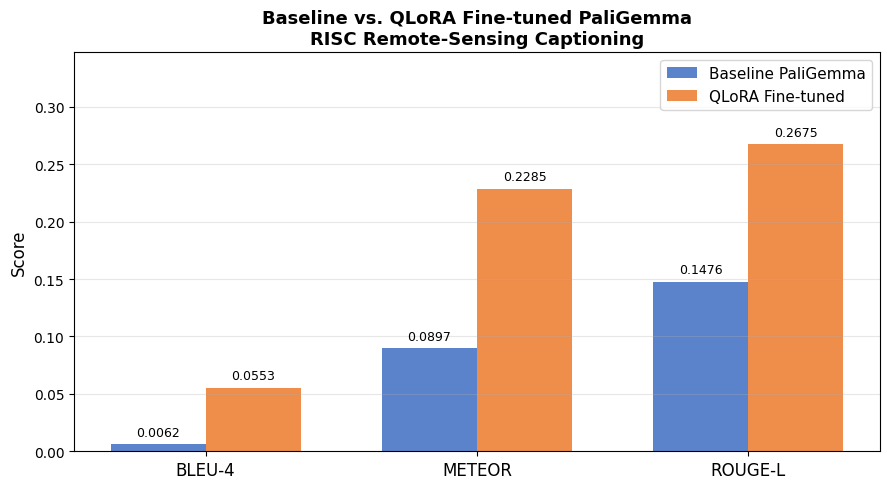

Saved metrics_comparison.png


In [25]:
metrics   = ['BLEU-4', 'METEOR', 'ROUGE-L']
base_vals = [b_bleu, b_meteor, b_rouge]
ft_vals   = [f_bleu, f_meteor, f_rouge]

x, w = np.arange(len(metrics)), 0.35
fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - w/2, base_vals, w, label='Baseline PaliGemma', color='#4472C4', alpha=0.88)
bars2 = ax.bar(x + w/2, ft_vals,   w, label='QLoRA Fine-tuned',   color='#ED7D31', alpha=0.88)

for bars in (bars1, bars2):
    for b in bars:
        ax.annotate(f'{b.get_height():.4f}',
                    xy=(b.get_x() + b.get_width()/2, b.get_height()),
                    xytext=(0, 4), textcoords='offset points',
                    ha='center', va='bottom', fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Baseline vs. QLoRA Fine-tuned PaliGemma\nRISC Remote-Sensing Captioning',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, max(ft_vals + base_vals) * 1.3)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved metrics_comparison.png')

In [26]:
print('=' * 58)
print('FINAL SUMMARY')
print('=' * 58)
print(f'Model         : PaliGemma-3B  ({MODEL_ID})')
print(f'Dataset       : RISC full  ({DATASET_ID})')
print(f'Caption col   : {CAPTION_COL!r}')
print(f'Train samples : {len(train_ds):,}')
print(f'Test samples  : {n_metric}')
print(f'LoRA          : r={LORA_R}, target all linear layers in LM')
print(f'Eff. batch    : {TRAIN_BATCH * GRAD_ACCUM}   LR: {LR}')
print()
print(f'              Baseline  →  QLoRA FT   (Δ)')
print(f'  BLEU-4  :   {b_bleu:.4f}  →  {f_bleu:.4f}   ({f_bleu-b_bleu:+.4f})')
print(f'  METEOR  :   {b_meteor:.4f}  →  {f_meteor:.4f}   ({f_meteor-b_meteor:+.4f})')
print(f'  ROUGE-L :   {b_rouge:.4f}  →  {f_rouge:.4f}   ({f_rouge-b_rouge:+.4f})')
print('=' * 58)

FINAL SUMMARY
Model         : PaliGemma-3B  (google/paligemma-3b-pt-224)
Dataset       : RISC full  (caglarmert/full_riscm)
Caption col   : 'caption_1'
Train samples : 42,294
Test samples  : 200
LoRA          : r=8, target all linear layers in LM
Eff. batch    : 16   LR: 2e-05

              Baseline  →  QLoRA FT   (Δ)
  BLEU-4  :   0.0062  →  0.0553   (+0.0491)
  METEOR  :   0.0897  →  0.2285   (+0.1388)
  ROUGE-L :   0.1476  →  0.2675   (+0.1198)
